In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('training_table_id69.csv')
df
dff=pd.read_csv('test_table_id69.csv')
df

,Day,Outlook,Temp,TempCat,Humidity(%),HumidityCat,Wind,PlayTennis
0,D1,Sunny,38,Hot,82,High,Weak,No
1,D2,Sunny,36,Hot,81,High,Strong,No
2,D3,Overcast,35,Hot,90,High,Weak,Yes
3,D4,Rain,25,Cool,75,High,Weak,Yes
4,D5,Rain,20,Cool,56,Normal,Weak,Yes
5,D6,Rain,18,Cool,65,Normal,Strong,No
6,D7,Overcast,22,Cool,72,Normal,Strong,Yes
7,D8,Sunny,21,Cool,86,High,Weak,No
8,D9,Sunny,27,Mild,70,Normal,Weak,Yes
9,D10,Rain,23,Cool,68,Normal,Weak,Yes


In [2]:
df = df.drop(columns=['Temp', 'Humidity(%)','Day'], axis=1)
df
dff = dff.drop(columns=['Temp', 'Humidity(%)','Day'], axis=1)
dff

,Outlook,TempCat,HumidityCat,Wind,PlayTennis
0,Sunny,Hot,High,Strong,Yes
1,Sunny,Hot,High,Strong,Yes
2,Overcast,Hot,High,Weak,No
3,Overcast,Mild,High,Strong,No
4,Rain,Cool,Normal,Strong,No
5,Rain,Cool,Normal,Weak,No
6,Sunny,Mild,High,Strong,Yes
7,Overcast,Cool,Normal,Weak,Yes


In [3]:
from sklearn.preprocessing import LabelEncoder

# List of columns to encode
columns_to_encode = ['Outlook', 'Wind', 'PlayTennis', 'TempCat', 'HumidityCat']

# Create a new LabelEncoder instance and apply it to each column
for column in columns_to_encode:
    le = LabelEncoder()  # New instance for each column
    df[column] = le.fit_transform(df[column])

# Display the resulting DataFrame

for column in columns_to_encode:
    le = LabelEncoder()  # New instance for each column
    dff[column] = le.fit_transform(dff[column])
    
df



ModuleNotFoundError: No module named 'sklearn'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from math import log2

def calculate_entropy(data):
    """Calculate entropy of a dataset"""
    if len(data) == 0:
        return 0

    # Count occurrences of each class
    class_counts = data.value_counts()
    total_samples = len(data)

    entropy = 0
    for count in class_counts:
        probability = count / total_samples
        if probability > 0:
            entropy -= probability * log2(probability)

    return entropy

def main():
    # Load and preprocess data (same as in your notebook)
    df = pd.read_csv('training_table_id69.csv')
    dff = pd.read_csv('test_table_id69.csv')

    df = df.drop(columns=['Temp', 'Humidity(%)','Day'], axis=1)
    dff = dff.drop(columns=['Temp', 'Humidity(%)','Day'], axis=1)

    # List of columns to encode
    columns_to_encode = ['Outlook', 'Wind', 'PlayTennis', 'TempCat', 'HumidityCat']

    # Create a new LabelEncoder instance and apply it to each column
    for column in columns_to_encode:
        le = LabelEncoder()  # New instance for each column
        df[column] = le.fit_transform(df[column])

    for column in columns_to_encode:
        le = LabelEncoder()  # New instance for each column
        dff[column] = le.fit_transform(dff[column])

    # Prepare features and target
    X = df.drop(columns=['PlayTennis'], axis=1)
    Y = df['PlayTennis']
    x = dff.drop(columns=['PlayTennis'], axis=1)
    y = dff['PlayTennis']

    # Create and train the model
    model = tree.DecisionTreeClassifier()
    model.fit(X, Y)

    # Model evaluation
    y_pred = model.predict(x)
    print("=== MODEL PERFORMANCE METRICS ===")
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred):.4f}")
    print(f"Recall: {recall_score(y, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y, y_pred):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y, y_pred)}")

    # === ENTROPY AND INFORMATION GAIN ANALYSIS ===
    print("\n" + "="*50)
    print("ATTRIBUTE ENTROPY AND INFORMATION GAIN ANALYSIS")
    print("="*50)

    # Calculate entropy for each attribute
    print("\n=== ATTRIBUTE ENTROPY ANALYSIS ===")
    print(f"Target variable (PlayTennis) entropy: {calculate_entropy(Y):.4f}")

    feature_names = X.columns.tolist()
    print("\nIndividual Attribute Entropies:")
    for feature in feature_names:
        entropy = calculate_entropy(X[feature])
        print(f"  {feature}: {entropy:.4f}")

    # Calculate information gain for each attribute
    print("\n=== INFORMATION GAIN ANALYSIS ===")
    target_entropy = calculate_entropy(Y)

    print(f"Target entropy: {target_entropy:.4f}")
    print("\nInformation Gain for each attribute:")

    for feature in feature_names:
        # Calculate weighted entropy for each feature value
        weighted_entropy = 0
        for value in X[feature].unique():
            subset = Y[X[feature] == value]
            weight = len(subset) / len(Y)
            weighted_entropy += weight * calculate_entropy(subset)

        information_gain = target_entropy - weighted_entropy
        print(f"  {feature}: {information_gain:.4f}")

    # Show which attribute has the highest information gain
    print("\n=== ATTRIBUTE SELECTION BASED ON INFORMATION GAIN ===")
    gains = {}
    for feature in feature_names:
        weighted_entropy = 0
        for value in X[feature].unique():
            subset = Y[X[feature] == value]
            weight = len(subset) / len(Y)
            weighted_entropy += weight * calculate_entropy(subset)
        gains[feature] = target_entropy - weighted_entropy

    best_attribute = max(gains, key=gains.get)
    print(f"Best attribute to split on (highest information gain): {best_attribute}")
    print(f"Information gain: {gains[best_attribute]:.4f}")

    # Display attribute ranking
    print("\nAttribute ranking by information gain:")
    sorted_gains = sorted(gains.items(), key=lambda x: x[1], reverse=True)
    for i, (attr, gain) in enumerate(sorted_gains, 1):
        print(f"  {i}. {attr}: {gain:.4f}")

if __name__ == "__main__":
    main()


=== MODEL PERFORMANCE METRICS ===
Accuracy: 0.2500
Precision: 0.2500
Recall: 0.2500
F1 Score: 0.2500
Confusion Matrix:
[[1 3]
 [3 1]]

ATTRIBUTE ENTROPY AND INFORMATION GAIN ANALYSIS

=== ATTRIBUTE ENTROPY ANALYSIS ===
Target variable (PlayTennis) entropy: 0.9403

Individual Attribute Entropies:
  Outlook: 1.5774
  TempCat: 1.4926
  HumidityCat: 1.0000
  Wind: 0.9852

=== INFORMATION GAIN ANALYSIS ===
Target entropy: 0.9403

Information Gain for each attribute:
  Outlook: 0.2467
  TempCat: 0.0802
  HumidityCat: 0.1518
  Wind: 0.0481

=== ATTRIBUTE SELECTION BASED ON INFORMATION GAIN ===
Best attribute to split on (highest information gain): Outlook
Information gain: 0.2467

Attribute ranking by information gain:
  1. Outlook: 0.2467
  2. HumidityCat: 0.1518
  3. TempCat: 0.0802
  4. Wind: 0.0481


In [ ]:
import pandas as pd
import numpy as np

def main():
    # Load the dataset
    df = pd.read_csv('training_table_id69.csv')

    print("TENNIS DATASET - DUMMY TABLES ANALYSIS")
    print("="*50)
    print("Target: PlayTennis (Yes/No)")
    print("="*50)

    # Get attributes to analyze
    attributes = ['Outlook', 'TempCat', 'HumidityCat', 'Wind']

    for attribute in attributes:
        print(f"\n{attribute.upper()} - DUMMY TABLE")
        print("-" * 30)

        # Create contingency table
        dummy_table = pd.crosstab(df[attribute], df['PlayTennis'])
        print(dummy_table)

        # Add totals
        dummy_table_with_totals = pd.crosstab(df[attribute], df['PlayTennis'], margins=True, margins_name="Total")
        print(f"\n{attribute} with totals:")
        print(dummy_table_with_totals)

        # Calculate percentages
        print(f"\n{attribute} - Percentage breakdown:")
        print("-" * 30)
        for value in df[attribute].unique():
            yes_count = len(df[(df[attribute] == value) & (df['PlayTennis'] == 'Yes')])
            no_count = len(df[(df[attribute] == value) & (df['PlayTennis'] == 'No')])
            total = yes_count + no_count

            if total > 0:
                yes_pct = (yes_count / total) * 100
                no_pct = (no_count / total) * 100
                print(f"  {value}:")
                print(f"    Yes: {yes_count}/{total} ({yes_pct:.1f}%)")
                print(f"    No:  {no_count}/{total} ({no_pct:.1f}%)")

if __name__ == "__main__":
    main()


TENNIS DATASET - DUMMY TABLES ANALYSIS
Target: PlayTennis (Yes/No)

OUTLOOK - DUMMY TABLE
------------------------------
PlayTennis  No  Yes
Outlook            
Overcast     0    4
Rain         2    3
Sunny        3    2

Outlook with totals:
PlayTennis  No  Yes  Total
Outlook                   
Overcast     0    4      4
Rain         2    3      5
Sunny        3    2      5
Total        5    9     14

Outlook - Percentage breakdown:
------------------------------
  Sunny:
    Yes: 2/5 (40.0%)
    No:  3/5 (60.0%)
  Overcast:
    Yes: 4/4 (100.0%)
    No:  0/4 (0.0%)
  Rain:
    Yes: 3/5 (60.0%)
    No:  2/5 (40.0%)

TEMPCAT - DUMMY TABLE
------------------------------
PlayTennis  No  Yes
TempCat            
Cool         2    5
Hot          2    1
Mild         1    3

TempCat with totals:
PlayTennis  No  Yes  Total
TempCat                   
Cool         2    5      7
Hot          2    1      3
Mild         1    3      4
Total        5    9     14

TempCat - Percentage breakdown:
-----

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

X=df.drop(columns=['PlayTennis'],axis=1)
Y=df['PlayTennis']
x=dff.drop(columns=['PlayTennis'],axis=1)
y=dff['PlayTennis']

model=tree.DecisionTreeClassifier()
model.fit(X,Y)

model.score(x,y)

y_pred=model.predict(x)
print(accuracy_score(y,y_pred))
print(precision_score(y,y_pred))
print(recall_score(y,y_pred))
print(f1_score(y,y_pred))
print(confusion_matrix(y,y_pred))


0.25
0.25
0.25
0.25
[[1 3]
 [3 1]]


In [ ]:
import pandas as pd
import numpy as np
from math import log, exp

# ---------- Helpers: binning & normalization ----------
def bin_temperature(t):
    if pd.isna(t): return np.nan
    try: t = float(t)
    except: return np.nan
    if t <= 65:   return "Cool"
    elif t <= 80: return "Mild"
    else:         return "Hot"

def bin_humidity(h):
    if pd.isna(h): return np.nan
    try: h = float(h)
    except: return np.nan
    return "High" if h >= 75 else "Normal"

def normalize_wind(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    truthy = {"1","true","t","yes","y","strong"}
    falsy  = {"0","false","f","no","n","weak"}
    if s in truthy: return "Strong"
    if s in falsy:  return "Weak"
    return str(x).strip().title()

def tidy_columns(df):
    df.columns = [c.strip().replace("\xa0", " ") for c in df.columns]
    return df

def pick_col(df, *cands):
    low = {c.lower(): c for c in df.columns}
    for c in cands:
        if c in df.columns: return c
        if c.lower() in low: return low[c.lower()]
    return None

def normalize_target(series):
    # Map to "Yes"/"No"
    s = series.astype("string").str.strip().str.lower()
    mapping = {
        "y": "Yes", "yes":"Yes", "1":"Yes", "true":"Yes", "t":"Yes",
        "n": "No",  "no":"No",  "0":"No",  "false":"No",  "f":"No"
    }
    out = s.map(mapping)
    out = out.fillna(series.astype("string").str.strip().str.title())
    unique = set(out.dropna().unique())
    if not unique.issubset({"Yes","No"}):
        raise ValueError(f"Target must be Yes/No, but got values: {sorted(unique)}")
    return out

# ---------- Train: categorical Naive Bayes (with Laplace smoothing) ----------
class CategoricalNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_counts_ = None
        self.class_priors_ = None
        self.feature_values_ = dict()
        self.counts_ = dict()

    def fit(self, df, features, target):
        y = df[target]
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_counts_ = {c: int(n) for c, n in zip(self.classes_, counts)}
        total = sum(self.class_counts_.values())
        self.class_priors_ = {c: self.class_counts_[c]/total for c in self.classes_}

        for feat in features:
            vals = df[feat].dropna().astype("string").str.strip().unique()
            vals = sorted([v for v in vals if v != ""])
            self.feature_values_[feat] = vals
            self.counts_[feat] = {}
            for c in self.classes_:
                self.counts_[feat][c] = {}
                subset = df.loc[y==c, feat].astype("string").str.strip()
                vc = subset.value_counts()
                for v in vals:
                    self.counts_[feat][c][v] = int(vc.get(v, 0))

    def _cond_prob(self, feat, value, cls):
        V = len(self.feature_values_.get(feat, []))
        count_c = self.class_counts_[cls]
        count_vc = self.counts_.get(feat, {}).get(cls, {}).get(value, 0)
        denom = count_c + self.alpha * max(V, 1)
        return (count_vc + self.alpha) / denom

    def predict_proba_row(self, row, features):
        log_post = {}
        for c in self.classes_:
            lp = log(self.class_priors_[c])
            for feat in features:
                val = row.get(feat, np.nan)
                if pd.isna(val): 
                    continue
                val = str(val).strip()
                if val == "": 
                    continue
                lp += log(self._cond_prob(feat, val, c))
            log_post[c] = lp
        m = max(log_post.values())
        exped = {c: exp(log_post[c]-m) for c in log_post}
        Z = sum(exped.values())
        return {c: exped[c]/Z for c in exped}

# ---------- Metrics (binary Yes vs No) ----------
def confusion_and_metrics(y_true, y_pred, positive="Yes"):
    y_true = pd.Series(y_true).astype(str)
    y_pred = pd.Series(y_pred).astype(str)
    pos = positive
    neg = "No" if positive == "Yes" else "Yes"

    tp = int(((y_true == pos) & (y_pred == pos)).sum())
    tn = int(((y_true == neg) & (y_pred == neg)).sum())
    fp = int(((y_true == neg) & (y_pred == pos)).sum())
    fn = int(((y_true == pos) & (y_pred == neg)).sum())
    n = tp + tn + fp + fn

    acc = (tp + tn) / n if n else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0

    cm = pd.DataFrame(
        [[tp, fn],
         [fp, tn]],
        index=[f"True {pos}", f"True {neg}"],
        columns=[f"Pred {pos}", f"Pred {neg}"]
    )

    return cm, {
        "accuracy": acc,
        "precision_pos": prec,
        "recall_pos": rec,
        "f1_pos": f1
    }

# ---------- Pipeline to load, prep, fit, score, and evaluate ----------
def main():
    TRAIN_PATH = "training_table_id69.csv"
    TEST_PATH  = "test_table_id69.csv"
    ALPHA = 1.0  # Laplace smoothing

    train = tidy_columns(pd.read_csv(TRAIN_PATH))
    test  = tidy_columns(pd.read_csv(TEST_PATH))

    # Identify/normalize target
    target = pick_col(train, "PlayTennis", "Play Tennis", "Play", "Target")
    if target is None:
        raise KeyError("Target column not found in train file (try PlayTennis / Play Tennis / Play / Target).")
    train[target] = normalize_target(train[target])

    # Ensure/derive categorical features
    outlook = pick_col(train, "Outlook")
    temp_cat = pick_col(train, "Temp_Category", "Temperature_Category", "Temp Category")
    if temp_cat is None:
        temp_raw = pick_col(train, "Temperature", "Temp")
        if temp_raw is not None:
            train["Temp_Category"] = train[temp_raw].apply(bin_temperature)
            temp_cat = "Temp_Category"
    if temp_cat and temp_cat not in test.columns:
        temp_raw_t = pick_col(test, "Temperature", "Temp")
        if temp_raw_t is not None:
            test["Temp_Category"] = test[temp_raw_t].apply(bin_temperature)

    hum_cat = pick_col(train, "Humidity_Category", "Humidity Category")
    if hum_cat is None:
        hum_raw = pick_col(train, "Humidity")
        if hum_raw is not None:
            train["Humidity_Category"] = train[hum_raw].apply(bin_humidity)
            hum_cat = "Humidity_Category"
    if hum_cat and hum_cat not in test.columns:
        hum_raw_t = pick_col(test, "Humidity")
        if hum_raw_t is not None:
            test["Humidity_Category"] = test[hum_raw_t].apply(bin_humidity)

    wind = pick_col(train, "Wind", "Windy")
    if wind is not None:
        train[wind] = train[wind].apply(normalize_wind)
        if wind in test.columns:
            test[wind] = test[wind].apply(normalize_wind)

    # Feature list present in BOTH train and test
    possible = [outlook, temp_cat, hum_cat, wind]
    features = [f for f in possible if f and f in train.columns and f in test.columns]
    if not features:
        raise ValueError("No common categorical features found in both train and test after preprocessing.")

    # Fit NB
    nb = CategoricalNB(alpha=ALPHA)
    nb.fit(train, features, target)

    # Row IDs
    id_col = pick_col(test, "ID", "Id", "Case", "Row", "Example")
    if id_col is None:
        test_id = [f"D{i+1}" for i in range(len(test))]
    else:
        test_id = test[id_col].astype("string").fillna("").tolist()

    # Predict probabilities & labels on TEST
    rows, y_pred = [], []
    for idx, row in test.iterrows():
        post = nb.predict_proba_row(row, features)
        p_yes = post.get("Yes", 0.0)
        p_no  = post.get("No", 0.0)
        pred  = "Yes" if p_yes >= p_no else "No"
        y_pred.append(pred)
        rows.append({
            "RowID": test_id[idx] if idx < len(test_id) else f"Row{idx}",
            "P(Yes|row)": round(p_yes, 6),
            "P(No|row)":  round(p_no, 6),
            "Predicted": pred
        })
    result = pd.DataFrame(rows, columns=["RowID", "P(Yes|row)", "P(No|row)", "Predicted"])

    print("\nNAIVE BAYES – Test Posterior Probabilities")
    print(result.to_string(index=False))

    # Example: D15 row
    d15 = result[result["RowID"].astype(str).str.upper() == "D15"]
    if not d15.empty:
        r = d15.iloc[0]
        print(f"\nExample for {r['RowID']}:")
        print(f"  P(Yes|{r['RowID']}) = {r['P(Yes|row)']}")
        print(f"  P(No|{r['RowID']})  = {r['P(No|row)']}")
    else:
        print("\nNote: No row labeled 'D15' found in the test table.")

    # ---- Metrics ----
    # Try to use TEST labels if available; otherwise fall back to TRAIN resubstitution metrics.
    test_target_col = pick_col(test, target)  # same name if present
    if test_target_col is not None:
        # Compute metrics on TEST
        y_true = normalize_target(test[test_target_col])
        # Align lengths (drop any rows with missing ground truth)
        valid_mask = y_true.notna()
        y_true_valid = y_true[valid_mask]
        y_pred_valid = pd.Series(y_pred)[valid_mask.values]
        cm, metrics = confusion_and_metrics(y_true_valid, y_pred_valid, positive="Yes")

        print("\nCONFUSION MATRIX (Test)")
        print(cm.to_string())
        print("\nMETRICS (Test, positive = 'Yes')")
        print(f"  Accuracy : {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision_pos']:.4f}")
        print(f"  Recall   : {metrics['recall_pos']:.4f}")
        print(f"  F1-score : {metrics['f1_pos']:.4f}")
    else:
        print("\nNo ground-truth target found in Ass2.csv; computing TRAIN-set metrics instead (resubstitution).")
        # Predict on TRAIN for a rough sanity check (resubstitution)
        y_true_train = train[target]
        y_pred_train = []
        for _, row in train.iterrows():
            post = nb.predict_proba_row(row, features)
            y_pred_train.append("Yes" if post.get("Yes", 0.0) >= post.get("No", 0.0) else "No")
        cm, metrics = confusion_and_metrics(y_true_train, y_pred_train, positive="Yes")

        print("\nCONFUSION MATRIX (Train / Resubstitution)")
        print(cm.to_string())
        print("\nMETRICS (Train / Resubstitution, positive = 'Yes')")
        print(f"  Accuracy : {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision_pos']:.4f}")
        print(f"  Recall   : {metrics['recall_pos']:.4f}")
        print(f"  F1-score : {metrics['f1_pos']:.4f}")
        print("\nTip: To get **test** metrics, add the target column (e.g., 'PlayTennis') to Ass2.csv.")

if __name__ == "__main__":
    main()



NAIVE BAYES – Test Posterior Probabilities
RowID  P(Yes|row)  P(No|row) Predicted
   D1    0.364162   0.635838        No
   D2    0.364162   0.635838        No
   D3    0.899083   0.100917       Yes
   D4    0.792453   0.207547       Yes
   D5    0.504505   0.495495       Yes
   D6    0.703770   0.296230       Yes
   D7    0.364162   0.635838        No
   D8    0.899083   0.100917       Yes

Note: No row labeled 'D15' found in the test table.

CONFUSION MATRIX (Test)
          Pred Yes  Pred No
True Yes         1        3
True No          4        0

METRICS (Test, positive = 'Yes')
  Accuracy : 0.1250
  Precision: 0.2000
  Recall   : 0.2500
  F1-score : 0.2222


In [ ]:
import xarray as xr
import pandas as pd

# Open dataset
ds = xr.open_dataset(r"data11.nc")

# Select the variable you want, e.g., precipitation
da = ds['precipitation']

# Convert to a DataFrame
df = da.to_dataframe().reset_index()

# Save to CSV
df.to_csv("precipitation.csv", index=False)

print("Saved to precipitation.csv")
dff=pd.read_csv('precipitation.csv')
dff


Saved to precipitation.csv


,time,lat,lon,precipitation
0,2022-01-30,-89.5,-179.5,0.0
1,2022-01-30,-89.5,-178.5,0.0
2,2022-01-30,-89.5,-177.5,NaN
3,2022-01-30,-89.5,-176.5,NaN
4,2022-01-30,-89.5,-175.5,NaN
...,...,...,...,...
64795,2022-01-30,89.5,175.5,NaN
64796,2022-01-30,89.5,176.5,NaN
64797,2022-01-30,89.5,177.5,NaN
64798,2022-01-30,89.5,178.5,0.0


In [2]:
import pandas as pd

# Load (no header in your paste)
df = pd.read_csv("water_volume_raw.csv", header=None, names=["date_raw", "volume_km3"])

# Parse the YYYYMMDD into a real datetime
df["date"] = pd.to_datetime(df["date_raw"].astype(str), format="%Y%m%d", errors="coerce")

# Drop any rows where date failed to parse (should be rare)
df = df.dropna(subset=["date"])

# Sort by date
df = df.sort_values("date", ignore_index=True)

# (A) If you want to KEEP the first occurrence for duplicate dates
df_nodup_first = df.drop_duplicates(subset="date", keep="first")

# (B) If you prefer to AVERAGE duplicate dates
df_avg = df.groupby("date", as_index=False)["volume_km3"].mean().sort_values("date")


In [3]:
# choose one of the cleaned dataframes
df_clean = df_avg  # or df_nodup_first

df_clean.to_csv("water_volume_clean.csv", index=False)
df_clean.head()


,date,volume_km3
0,2016-02-01,0.151026
1,2016-02-25,0.025093
2,2016-04-13,0.030658
3,2016-04-29,0.028261
4,2016-05-25,0.018992


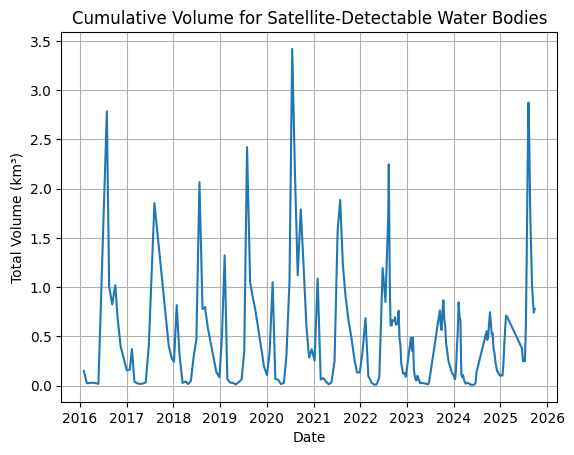

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_clean["date"], df_clean["volume_km3"])
plt.xlabel("Date")
plt.ylabel("Total Volume (km³)")
plt.title("Cumulative Volume for Satellite-Detectable Water Bodies")
plt.grid(True)
plt.show()


In [5]:
monthly = df_clean.set_index("date")["volume_km3"].resample("M").mean().reset_index()
monthly.to_csv("water_volume_monthly.csv", index=False)
monthly.head()


C:\Users\adelz\AppData\Local\Temp\ipykernel_10556\3142698261.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_clean.set_index("date")["volume_km3"].resample("M").mean().reset_index()


,date,volume_km3
0,2016-02-29,0.088059
1,2016-03-31,NaN
2,2016-04-30,0.029459
3,2016-05-31,0.018992
4,2016-06-30,NaN
